In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('/content/augmented_data.csv')
df.head()

,T2M,T2MDEW,TS,T2M_RANGE,QV2M,RH2M,GWETTOP,GWETROOT,1_month_rainfall_aggregate,1_month_rainfall_aggregate_avg
0,0.435871,0.876888,0.402809,0.326010,0.843991,0.734402,0.731110,0.580117,0.121731,0.262905
1,0.207624,0.748609,0.209399,0.222012,0.682044,0.815833,0.864177,0.831781,0.058485,0.148379
2,0.595267,0.641969,0.598176,0.649531,0.568077,0.367075,0.281054,0.072290,0.092778,0.359536
3,0.372425,0.838924,0.365360,0.329752,0.790515,0.758777,0.588839,0.363562,0.055531,0.178197
4,0.640929,0.564337,0.662026,0.710243,0.518174,0.281746,0.300164,0.093181,0.014651,0.238779


In [3]:
df.drop(columns=['1_month_rainfall_aggregate_avg'],inplace=True)
df.head()

,T2M,T2MDEW,TS,T2M_RANGE,QV2M,RH2M,GWETTOP,GWETROOT,1_month_rainfall_aggregate
0,0.435871,0.876888,0.402809,0.326010,0.843991,0.734402,0.731110,0.580117,0.121731
1,0.207624,0.748609,0.209399,0.222012,0.682044,0.815833,0.864177,0.831781,0.058485
2,0.595267,0.641969,0.598176,0.649531,0.568077,0.367075,0.281054,0.072290,0.092778
3,0.372425,0.838924,0.365360,0.329752,0.790515,0.758777,0.588839,0.363562,0.055531
4,0.640929,0.564337,0.662026,0.710243,0.518174,0.281746,0.300164,0.093181,0.014651


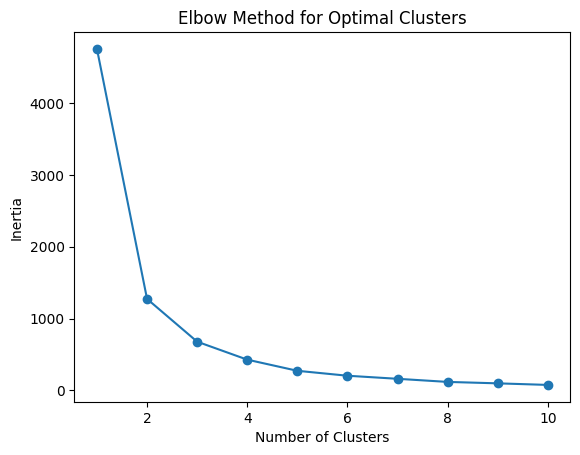

                    T2M    T2MDEW        TS  T2M_RANGE      QV2M      RH2M  \
Cluster_Label                                                                
0              0.581488  0.700577  0.581011   0.500224  0.649049  0.435156   
1              0.255488  0.687708  0.257156   0.285039  0.630590  0.716118   

                GWETTOP  GWETROOT  1_month_rainfall_aggregate  
Cluster_Label                                                  
0              0.338784  0.130874                    0.086345  
1              0.651435  0.482096                    0.230053  


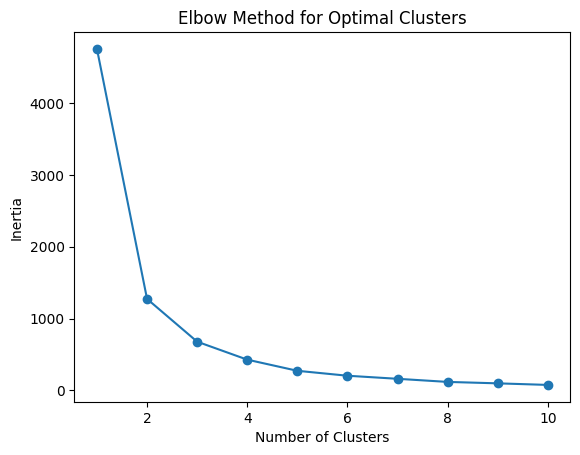

                    T2M    T2MDEW        TS  T2M_RANGE      QV2M      RH2M  \
Cluster_Label                                                                
0              0.581488  0.700577  0.581011   0.500224  0.649049  0.435156   
1              0.255488  0.687708  0.257156   0.285039  0.630590  0.716118   

                GWETTOP  GWETROOT  1_month_rainfall_aggregate  
Cluster_Label                                                  
0              0.338784  0.130874                    0.086345  
1              0.651435  0.482096                    0.230053  


In [6]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant features for clustering (excluding any date columns)
X = df.drop(columns=df.columns[1:])  # Adjust columns as necessary for your data

# Convert all columns in X to numeric, coercing errors to NaN
# This step ensures all columns can have a mean calculated
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Standardize the features (important for clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine the optimal number of clusters using the elbow method (optional)
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow graph to find the optimal number of clusters
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Clusters')
plt.show()

# Apply K-Means clustering (choose the number of clusters based on the elbow plot)
kmeans = KMeans(n_clusters=2, random_state=42)  # Assuming 2 clusters for 'Irrigate' and 'Do Not Irrigate'
df['Cluster_Label'] = kmeans.fit_predict(X_scaled)

# Interpret clusters based on feature values
print(df.groupby('Cluster_Label').mean(numeric_only=True))  # Analyze cluster characteristics to infer labels # Add numeric_only=True
# This step ensures all columns can have a mean calculated
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Standardize the features (important for clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Determine the optimal number of clusters using the elbow method (optional)
inertia = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the elbow graph to find the optimal number of clusters
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Clusters')
plt.show()

# Apply K-Means clustering (choose the number of clusters based on the elbow plot)
kmeans = KMeans(n_clusters=2, random_state=42)  # Assuming 2 clusters for 'Irrigate' and 'Do Not Irrigate'
df['Cluster_Label'] = kmeans.fit_predict(X_scaled)

# Interpret clusters based on feature values
print(df.groupby('Cluster_Label').mean(numeric_only=True))  # Analyze cluster characteristics to infer labels # Add numeric_only=True

In [7]:
print(df['Cluster_Label'].value_counts())

Cluster_Label
0    2793
1    1958
Name: count, dtype: int64


In [8]:
df['Irrigation_Label'] = df['Cluster_Label'].apply(lambda x: 'Irrigate' if x == 1 else 'Do Not Irrigate')

In [9]:
df.head()

,T2M,T2MDEW,TS,T2M_RANGE,QV2M,RH2M,GWETTOP,GWETROOT,1_month_rainfall_aggregate,Cluster_Label,Irrigation_Label
0,0.435871,0.876888,0.402809,0.326010,0.843991,0.734402,0.731110,0.580117,0.121731,0,Do Not Irrigate
1,0.207624,0.748609,0.209399,0.222012,0.682044,0.815833,0.864177,0.831781,0.058485,1,Irrigate
2,0.595267,0.641969,0.598176,0.649531,0.568077,0.367075,0.281054,0.072290,0.092778,0,Do Not Irrigate
3,0.372425,0.838924,0.365360,0.329752,0.790515,0.758777,0.588839,0.363562,0.055531,1,Irrigate
4,0.640929,0.564337,0.662026,0.710243,0.518174,0.281746,0.300164,0.093181,0.014651,0,Do Not Irrigate


                      Feature  Importance
0                         T2M    0.465959
2                          TS    0.304959
3                   T2M_RANGE    0.088141
7                    GWETROOT    0.046465
6                     GWETTOP    0.032370
4                        QV2M    0.024364
5                        RH2M    0.023135
1                      T2MDEW    0.011086
8  1_month_rainfall_aggregate    0.003520


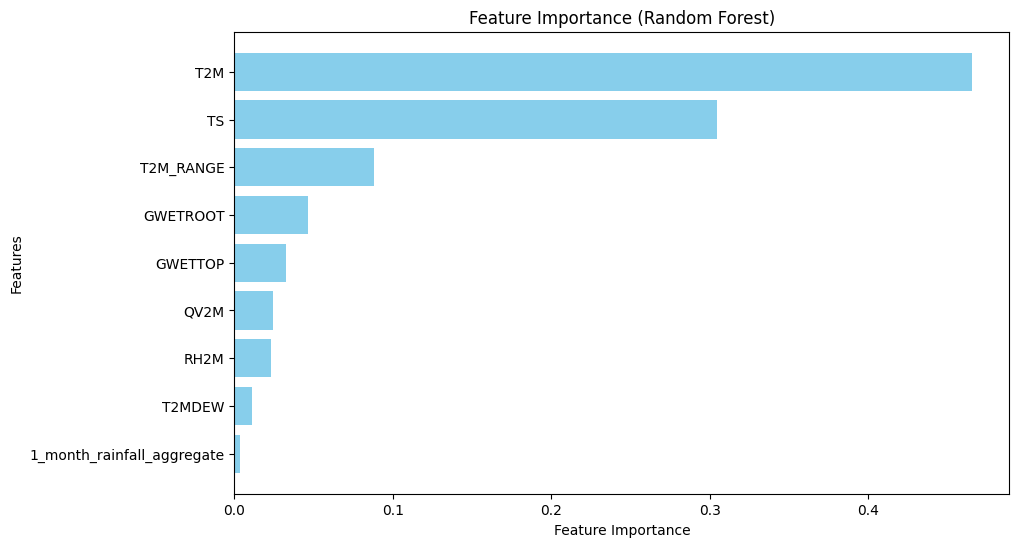

In [12]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

x_train=df.drop(columns=['Cluster_Label','Irrigation_Label'])
y_train=df['Cluster_Label']

# Train a Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

# Get feature importances
feature_importances = rf.feature_importances_

# Map feature importances to feature names
features = x_train.columns  # Feature names from your dataset
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})

# Sort features by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Display the top features
print(importance_df)

# Visualize the feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.show()


In [13]:
df['Irrigation_Label'].value_counts()

,count
Irrigation_Label,
Do Not Irrigate,2793
Irrigate,1958


In [14]:
df.to_csv('FINALSET.csv',index=False)

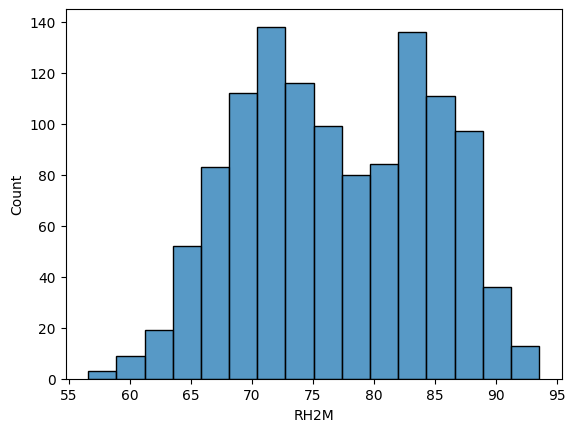

In [8]:
sns.histplot(df['RH2M'])
plt.show()


In [7]:
df.to_csv('not.csv',index=False)

In [10]:
labels=df['Irrigation_Label'].value_counts()
print(labels)

Irrigation_Label
Irrigate           951
Do Not Irrigate    237
Name: count, dtype: int64
